In [1]:
#Install Fitter module
#!pip install Fitter
#!pip install ruptures
#pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import sys
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.api import VAR
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import logging
import sys
import os
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from fitter import Fitter, get_common_distributions
import ruptures as rpt
import statsmodels.tsa.stattools as ts
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#8b949e'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['grid.color'] = '#30363d'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Color palette
BTC   = '#f7931a'
TEAL  = '#00d4aa'
PURP  = '#a78bfa'
RED   = '#f87171'
BLUE  = '#60a5fa'
YELL  = '#fbbf24'

try:
    from IPython.display import display
except ImportError:
    display = print

#from template.prelude_template import load_data
#from template.prelude_template import load_polymarket_data


In [3]:

cwd =  Path.cwd()
DATA_DIR=cwd / "data"

#We are using 2 datasets (crypto_fear_and_greed_index_2018_2024, SP500) which is needed for this notebook. 
#We can get this data from https://drive.google.com/drive/folders/1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif
#These 2 datasets should be placed under 'data' folder under script directory.


In [4]:
# --- Configuration ---
# Robustly determine the project root directory

# Setup: use eda_starter_template from this repo
import sys
from pathlib import Path


if (cwd / "eda" / "eda_starter_template.py").exists():
    #print("STEP 1")
    sys.path.insert(0, str(cwd))
    from eda.eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
elif (cwd / "eda_starter_template.py").exists():
    from eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
else:
    raise ImportError("Could not find eda_starter_template.py (run notebook from project root or eda/).")

print("Initial memory:", format_memory(get_memory_usage_mb()))

Initial memory: 254.94 MB


Common scripts 

In [5]:

def adf_test(df):
    result = adfuller(df.values)
    print('ADF Statistics: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))


def check_stationarity(series):
    # Copied from https://machinelearningmastery.com/time-series-data-stationary-python/

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")


def plot_acf_pacf(timeseries):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    plot_acf(timeseries, ax=ax1, lags=75)
    plot_pacf(timeseries, ax=ax2, lags=75)
    plt.show()

# Analysis based on BTC data 


In [6]:
#DATA_DIR = PROJECT_ROOT / "data"

COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

In [7]:
df_btc = pd.read_csv(COINMETRICS_PATH)
df_btc["time"] = pd.to_datetime(df_btc["time"])
df_btc.set_index("time", inplace=True)
df_btc.index = df_btc.index.normalize().tz_localize(None)

# Remove duplicates and sort
df_btc = df_btc.loc[~df_btc.index.duplicated(keep="last")].sort_index()
#df_btc=df_btc.dropna()
df_btc.head(2)

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
time,,,,,,,,,,,,,,,,,,,,,
2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN


Describe the data.

In [8]:
df_btc.describe()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
count,6.220000e+03,6.220000e+03,6.220000e+03,6.220000e+03,6220.000000,5659.000000,5.659000e+03,2.398000e+03,6220.000000,6220.000000,...,7.000000,7.000000,7.000000,6.220000e+03,6.220000e+03,5.659000e+03,6.214000e+03,6220.000000,6.220000e+03,5.659000e+03
mean,5.009057e+05,2.080860e+07,1.636422e+09,1.636422e+09,149.868810,1.989795,3.826396e+11,8.633915e+11,48.228897,25838.964889,...,29.161564,78563.321591,91487.781788,1.419667e+07,9.479984e+05,4.012445e+10,1.979521e+07,208414.228457,4.971118e+05,5.116673e+09
std,3.794394e+05,1.958234e+07,4.220227e+07,4.220227e+07,30.743195,2.493876,5.873727e+11,6.398350e+11,91.173237,24373.197547,...,0.295175,1441.867173,1711.761816,5.794621e+06,8.181572e+05,7.342693e+10,1.037226e+06,170293.817001,3.733056e+05,7.584967e+09
min,0.000000e+00,0.000000e+00,1.614335e+09,1.614335e+09,0.000000,0.386829,1.776705e+05,9.058570e+10,0.000000,0.000000,...,28.686314,77790.505193,90406.142411,0.000000e+00,0.000000e+00,0.000000e+00,1.707025e+07,0.000000,0.000000e+00,0.000000e+00
25%,6.069600e+04,1.374226e+06,1.614336e+09,1.614336e+09,137.000000,1.294023,3.672256e+09,3.553683e+11,8.206849,9739.439215,...,28.988983,77950.803938,90628.404772,1.100396e+07,8.793724e+04,8.975455e+07,1.916582e+07,47152.500000,1.043238e+05,1.057649e+07
50%,5.968805e+05,1.830680e+07,1.614337e+09,1.614337e+09,150.000000,1.754254,9.793110e+10,6.989680e+11,19.542053,21445.549012,...,29.300019,78130.277588,91096.916155,1.643875e+07,8.140561e+05,7.592223e+09,2.019138e+07,224415.500000,5.578790e+05,1.349240e+09
75%,8.175268e+05,3.851661e+07,1.634030e+09,1.634030e+09,162.000000,2.256760,5.545583e+11,1.237536e+12,45.831708,34086.280950,...,29.340685,78152.300810,91175.053055,1.884127e+07,1.533906e+06,4.227143e+10,2.062572e+07,312607.500000,7.981745e+05,8.188261e+09
max,1.366494e+06,5.592428e+07,1.768360e+09,1.768360e+09,692.000000,146.038332,2.487865e+12,2.487527e+12,1495.748916,284367.709273,...,29.485280,81816.258857,95304.498294,1.997535e+07,2.805575e+06,3.345030e+11,2.082639e+07,928131.000000,2.041653e+06,7.478639e+10


<b>Plot the BTC data.</b>

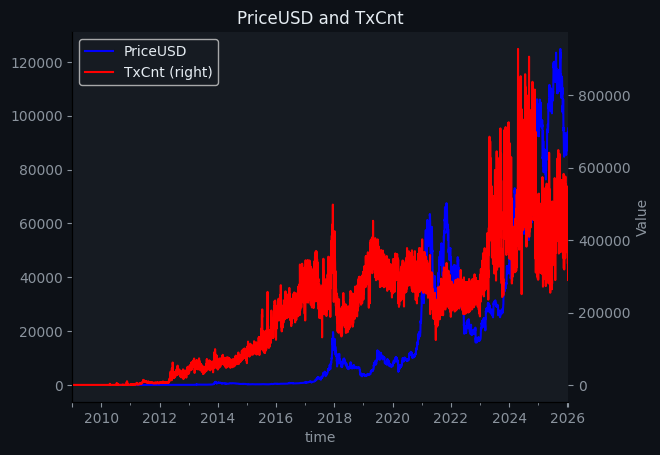

In [9]:
df2 = df_btc[['PriceUSD','CapMVRVCur','TxCnt']]
ax = df2.plot(y='PriceUSD', label='PriceUSD', color='blue')
df2.plot(y='TxCnt', label='TxCnt', color='red', ax=ax, secondary_y=True)
plt.title('PriceUSD and TxCnt')
plt.xlabel('Index')
plt.ylabel('Value')
#plt.legend()
plt.show()

<b>Do a seasonal decomposition using Multiplicative model and plot the data </b>

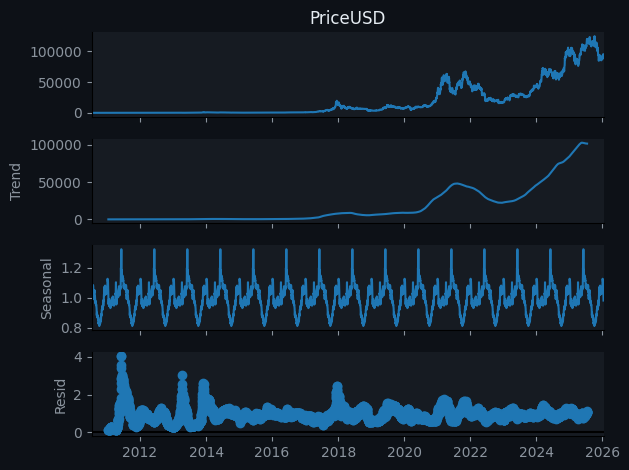

In [10]:
result = seasonal_decompose(df_btc['PriceUSD'].dropna(), model='multiplicative', period=365)  # Adjust period based on your data

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Save the results in decomposition_results with the column name as the key
decomposition_results = {
    'Close': {
        'trend': trend,
        'seasonal': seasonal,
        'residual': residual
    }
}

# Plot the decomposition
result.plot()
plt.tight_layout()
plt.show()

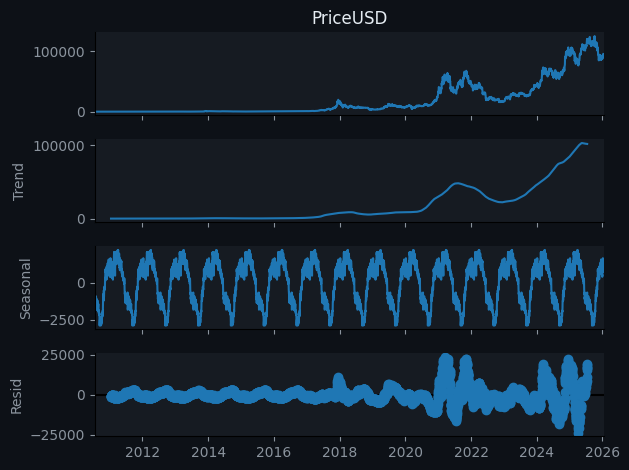

In [11]:
result = seasonal_decompose(df_btc['PriceUSD'].dropna(), model='additive', period=365)  # Adjust period based on your data

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Save the results in decomposition_results with the column name as the key
decomposition_results = {
    'Close': {
        'trend': trend,
        'seasonal': seasonal,
        'residual': residual
    }
}

# Plot the decomposition
result.plot()
plt.tight_layout()
plt.show()

Based on the residuals looks like multiplicative seems to be better. We see that there is a seasonal pattern.

<b>Plot of Moving averages of PriceUSD using log scale</b>

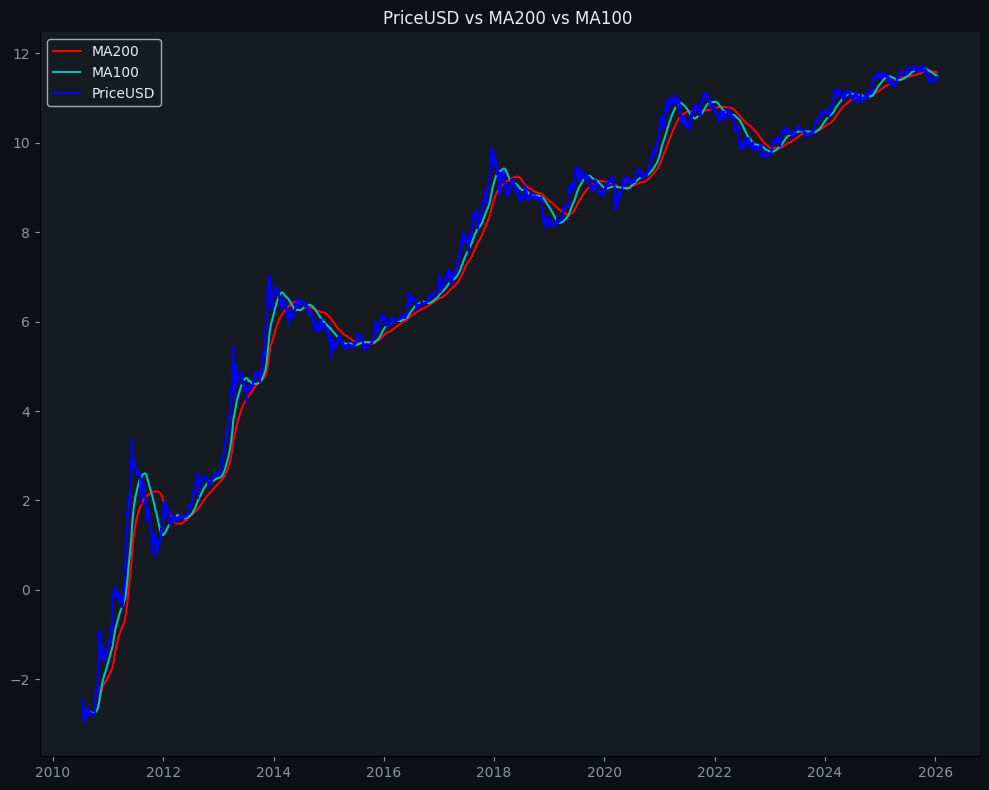

In [12]:
MA_WINDOW_200=200

ma_200 = df_btc['PriceUSD'].rolling(MA_WINDOW_200, min_periods=MA_WINDOW_200 // 2).mean()

MA_WINDOW_100=100
ma_100 = df_btc['PriceUSD'].rolling(MA_WINDOW_100, min_periods=MA_WINDOW_100 // 2).mean()
plt.figure(figsize=(10, 8))
plt.plot(np.log(ma_200), color='r', label='MA200')
plt.plot(np.log(ma_100), color='c', label='MA100')
plt.plot(np.log(df_btc['PriceUSD']), color='b', label='PriceUSD')
plt.title('PriceUSD vs MA200 vs MA100 ')
plt.legend()
plt.tight_layout()
plt.show()

From the above plot we see that when Moving average for 100 is above Moving average for 200, then the Price increases. When MA_100 is less than MA_200 then priceUSD drops.

<b>Check autocorrelation and stationarity of BTC PriceUSD data.</b>

PriceUSD is not stationary but first difference of PriceUSD is stationary.

In [13]:
px=df_btc['PriceUSD'].dropna()
check_stationarity(px)

ADF Statistic: -0.313816
p-value: 0.923525
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Non-stationary


In [14]:
px=df_btc['PriceUSD'].diff().dropna()
check_stationarity(px)

ADF Statistic: -11.262268
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Stationary


Plot the autocorrelation. There is a partial autocorrelation with periods 1,8,9

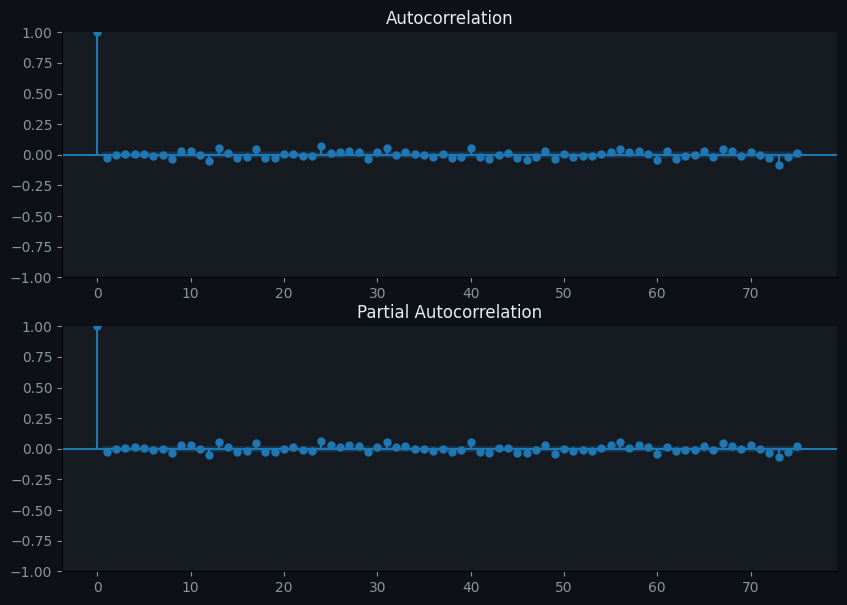

In [15]:
plot_acf_pacf(px)

<b>Plot the distribution of PriceUSD and try to get the bet fit for the data</b>
<br>
We see the PriceUSD follows  cauchy distribution/log normal distribution.

          sumsquare_error           aic           bic    kl_div  ks_statistic  \
cauchy           8.456708 -21393.566958 -21380.284953  0.275786      0.029961   
lognorm        260.896725 -18528.390115 -18508.467107  0.196437      0.128328   
norm           263.087028 -18491.436330 -18478.154325  0.198610      0.128935   
exponpow       685.316888 -10620.104574 -10600.181566  2.283586      0.343573   
rayleigh       856.809941  -4437.903095  -4424.621090  5.998715      0.478622   

             ks_pvalue  
cauchy    7.576113e-05  
lognorm   1.052510e-81  
norm      1.769834e-82  
exponpow  0.000000e+00  
rayleigh  0.000000e+00  
Best fitting distribution: cauchy


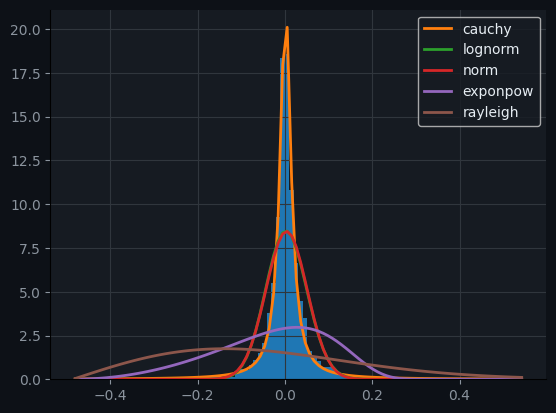

In [16]:
# Fit the data to common distributions
f = Fitter(df_btc['PriceUSD'].pct_change().dropna(), distributions=get_common_distributions())
f.fit()

# Print a summary of the best-fitting distributions
print(f.summary()) 

# You can also get the best fit distribution name and parameters
best_dist = f.get_best(method='aic') # 'aic', 'bic', or 'sumsquare_error'
print(f"Best fitting distribution: {list(best_dist.keys())[0]}")

Try to find distribution for year 2024/2025. We see the same distribution of data.

         sumsquare_error          aic          bic    kl_div  ks_statistic  \
cauchy        844.866424 -1712.146742 -1704.352434  1.882761      0.053277   
norm         1284.375181 -1743.810464 -1736.016156  1.749430      0.064815   
lognorm      1288.359162 -1742.368491 -1730.677030  1.747725      0.068469   
gamma        1296.753282 -1742.104376 -1730.412915  1.754219      0.071118   
chi2         1353.309819 -1738.877782 -1727.186321  1.812594      0.080921   

         ks_pvalue  
cauchy    0.243989  
norm      0.089857  
lognorm   0.062853  
gamma     0.047917  
chi2      0.016050  
Best fitting distribution: norm


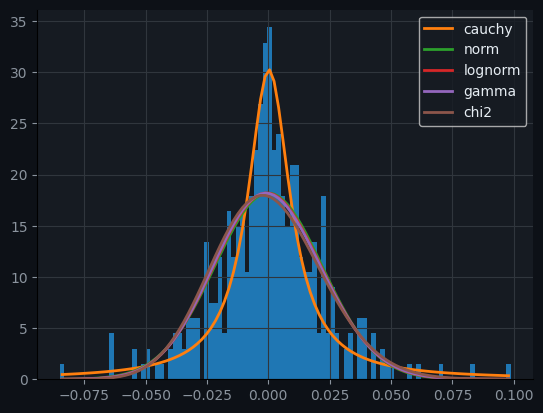

In [17]:
#Check the same for a given year. 
df_btc_2025=df_btc[df_btc.index.year == 2025]
f = Fitter(df_btc_2025['PriceUSD'].pct_change().dropna(), distributions=get_common_distributions())
f.fit()

# Print a summary of the best-fitting distributions
print(f.summary()) 

# You can also get the best fit distribution name and parameters
best_dist = f.get_best(method='aic') # 'aic', 'bic', or 'sumsquare_error'
print(f"Best fitting distribution: {list(best_dist.keys())[0]}")

<b>Correlation analysis and Autocorrelation based on timeseries data for year 2025. </b>
<br>
We see that correlation between PriceUSD and HashRate,TxCnt is much less during 2025 than historical correlation. This is very true for financial markets where correlation changes with time. We can see the plot of correlation between PriceUSD and HashRate for the various years.

In [18]:
correlation_cols = ["PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt"]
correlation_matrix = df_btc_2025[correlation_cols].corr()
print(correlation_matrix)

               PriceUSD  CapMrktCurUSD  HashRate     TxCnt
PriceUSD       1.000000       0.999821  0.211227  0.174687
CapMrktCurUSD  0.999821       1.000000  0.225319  0.181621
HashRate       0.211227       0.225319  1.000000  0.562812
TxCnt          0.174687       0.181621  0.562812  1.000000


In [19]:
correlation_cols = ["PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt"]
correlation_matrix = df_btc[correlation_cols].corr()
print(correlation_matrix)
correlation_matrix["PriceUSD"]["HashRate"]

               PriceUSD  CapMrktCurUSD  HashRate     TxCnt
PriceUSD       1.000000       0.999698  0.931277  0.661398
CapMrktCurUSD  0.999698       1.000000  0.937076  0.657791
HashRate       0.931277       0.937076  1.000000  0.710628
TxCnt          0.661398       0.657791  0.710628  1.000000


np.float64(0.9312774704411197)

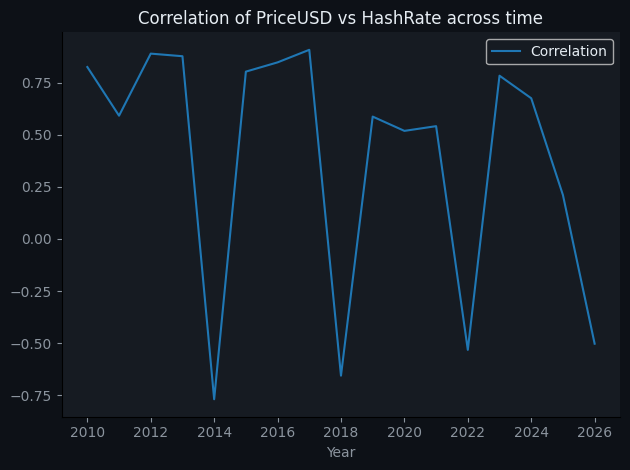

In [20]:
tmp=[]
years=[]
for year in df_btc.index.year.unique():
    #print(year)
    df_btc_year=df_btc[df_btc.index.year == year]
    correlation_matrix = df_btc_year[correlation_cols].corr()
    #print(correlation_matrix)
    tmp.append(correlation_matrix["PriceUSD"]["HashRate"])
    years.append(year)

my_dict = {
    'Year': years,
    'Correlation': tmp
}

# Create the DataFrame

df_2d = pd.DataFrame(my_dict)
df_2d.set_index('Year', inplace=True)

df_2d.plot()
plt.title("Correlation of PriceUSD vs HashRate across time")
plt.legend()
plt.tight_layout()
plt.show()

Check the BVAR regression.

In [21]:
tmp = df_btc_2025[correlation_cols]
tmp = tmp.diff().dropna()
model = VAR(tmp)
for i in range(1,20):

    result = model.fit(i)
    print('Lag Order =', i)
    print('AIC : ', result.aic)
    print('BIC : ', result.bic)
    print('FPE : ', result.fpe)
    print('HQIC: ', result.hqic, '\n')

Lag Order = 1
AIC :  110.8225926548473
BIC :  111.03716030411809
FPE :  1.3478559715364574e+48
HQIC:  110.90788226680091 

Lag Order = 2
AIC :  110.71826354493015
BIC :  111.10527788643769
FPE :  1.2143635061633834e+48
HQIC:  110.87211583236375 

Lag Order = 3
AIC :  110.74684831049125
BIC :  111.3070190967331
FPE :  1.249681194866346e+48
HQIC:  110.96955969533482 

Lag Order = 4
AIC :  110.75530608822147
BIC :  111.48934796082872
FPE :  1.260492865857348e+48
HQIC:  111.04717505508235 

Lag Order = 5
AIC :  110.73177792007122
BIC :  111.64041045665344
FPE :  1.2314943017543974e+48
HQIC:  111.09310503588878 

Lag Order = 6
AIC :  110.74111590764379
BIC :  111.82506366920823
FPE :  1.2435152187822661e+48
HQIC:  111.17220384158139 

Lag Order = 7
AIC :  110.70378810053485
BIC :  111.96378067948847
FPE :  1.1985814555527296e+48
HQIC:  111.20494164411234 

Lag Order = 8
AIC :  110.73550906836365
BIC :  112.17228113710654
FPE :  1.2380773505051274e+48
HQIC:  111.30703515583389 

Lag Order = 

In [22]:
model_fitted = model.fit(7)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Apr, 2026
Time:                     20:39:05
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    111.964
Nobs:                     357.000    HQIC:                   111.205
Log likelihood:          -21670.9    FPE:                1.19858e+48
AIC:                      110.704    Det(Omega_mle):     8.76983e+47
--------------------------------------------------------------------
Results for equation PriceUSD
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                 -218.724535       177.220993           -1.234           0.217
L1.PriceUSD            -49.545598        23.014903           -2.153           0.031
L1.CapMrktCurUSD         0.000002         0.0

We see that there is no autocorrelation based on timeseries data. (CapMrktCurUSD is a scaled version of PriceUSD)

Serial correlation of residuals is used to check if there is any leftover pattern in the residuals (errors).
If there is any correlation left in the residuals, then, there is some pattern in the time series that is still left to be explained by the model.
Durbin Watson’s Statistic is close to 2, then there is no significant serial correlation. 

In [23]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(tmp.columns, out):
    print((col), ':', round(val, 2))

PriceUSD : 1.99
CapMrktCurUSD : 1.99
HashRate : 2.0
TxCnt : 2.01


<b>
#Install ruptures library if needed
<br>
#!pip install ruptures
</b>

<b>Next we try to determine if there is any regime change.</b>
<br>
This needs ruptures module.

[55, 110, 125, 190, 230, 275, 285, 305, 315, 320, 365]


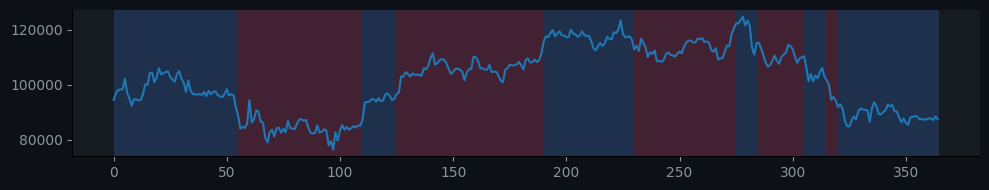

In [24]:
px=df_btc_2025['PriceUSD'].to_numpy()
algo = rpt.Dynp(model="l2").fit(px)
result = algo.predict(n_bkps=10)
print(result)
rpt.display(df_btc_2025['PriceUSD'],  result)
plt.show()

Determine the points where there is a regime change.

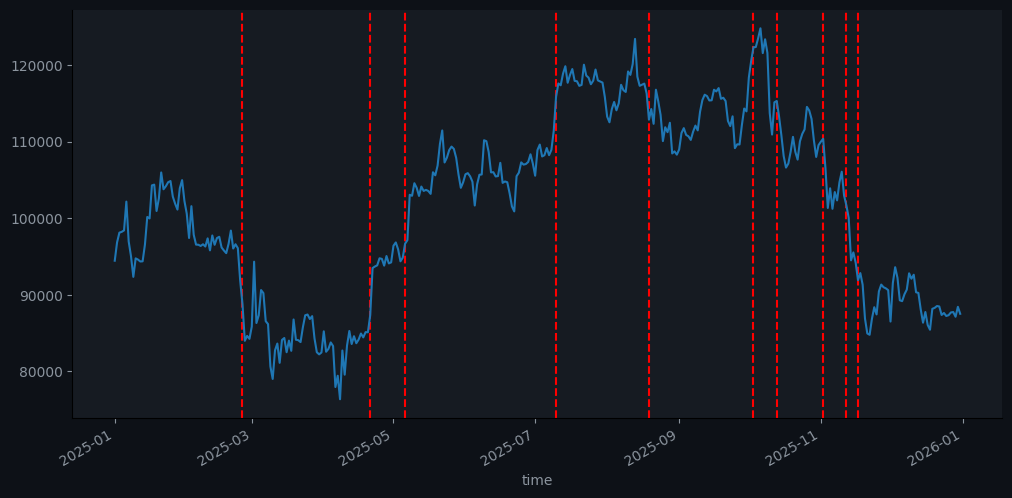

In [25]:
cnt=0
plt.figure(figsize=(12, 6))
for r in result[:-1]:
    plt.axvline(x=df_btc_2025.iloc[result[:-1]].index[cnt], color='red', linestyle='--', label='Regime change')
    cnt+=1

df_btc_2025['PriceUSD'].plot()
plt.show()

These are the dates where there is a regime change.

In [26]:
df_btc_2025.iloc[result[:-1]].index

DatetimeIndex(['2025-02-25', '2025-04-21', '2025-05-06', '2025-07-10',
               '2025-08-19', '2025-10-03', '2025-10-13', '2025-11-02',
               '2025-11-12', '2025-11-17'],
              dtype='datetime64[ns]', name='time', freq=None)

<table>
  <caption><b>Market events for regime change dates</b></caption>
  <thead>
    <tr>
      <th>Date</th>
      <th>Event</th>
      <th>Link</th>  
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>25-02-2025</td>
      <td>Nasdaq falls for 4th straight day.</td>
      <td>https://www.investopedia.com/dow-jones-today-02252025-11685876</td>  
    </tr>
    <tr>
      <td>2025-04-21</td>
      <td>Stocks Fall Sharply as Trump Ramps Up Criticism of Fed Chair Powell; Dollar Slides to 3-Year Low, Gold Jumps to New High</td>
        <td>https://www.investopedia.com/dow-jones-today-04212025-11718673</td>
    </tr>
    <tr>
      <td>2025-07-10</td>
      <td>Nasdaq Hit New Highs as Airline Stocks Soar After Strong Delta Earnings; Bitcoin Surges to Record</td>
        <td>https://www.investopedia.com/dow-jones-today-07102025-11769518</td>
    </tr>
    <tr>
      <td>2025-08-19</td>
      <td>Nasdaq Fall as Tech Stocks Tumble,Dow Closes Little Changed After Touching All-Time High</td>
        <td>https://www.investopedia.com/dow-jones-today-08192025-11793339</td>
    </tr>
   <tr>
      <td>2025-10-13</td>
      <td>Stocks Close Sharply Higher as Trump Softens Tone on China; Chip Shares Soar on Broadcom Deal With OpenAI</td>
        <td>https://www.investopedia.com/dow-jones-today-10132025-11828817</td>
    </tr>
    <tr>
      <td>2025-11-12</td>
      <td>Dow Closes Above 48000 for the First Time Ahead of House Vote to End US Government Shutdown; Nasdaq Slips</td>
        <td>https://www.investopedia.com/dow-jones-today-11122025-11847653</td>
    </tr>
    <tr>
      <td>2025-11-17</td>
      <td>Stock Indexes Close Down Sharply Ahead of Nvidia, Retail Results; Dow Sheds 550 Points; Google Parent Hits Record High</td>
        <td>https://www.investopedia.com/dow-jones-today-11172025-11850528</td>
    </tr>
      
  </tbody>
</table>


<b>This suggests a probable correlation with SP500. Hence we check with SP500 data for 2025.</b>

<br>
Open a New Google Sheet and Enter the Formula: In cell A1, enter the following formula to get the last ~15 years of daily data:
<br>
=GOOGLEFINANCE("INDEXSP:.INX", "all", DATE(2010,1,1), TODAY())
<br>


In [27]:
#sp_file=DATA_DIR/"SP500.csv"
sp_file = Path.cwd() / "data/SP500.csv"
df_sp500 = pd.read_csv(sp_file)
df_sp500['Date']=pd.to_datetime(df_sp500['Date'])
df_sp500 = df_sp500.set_index('Date')
df_sp500.index = df_sp500.index.normalize()

In [28]:
#sp_file,Path.cwd()

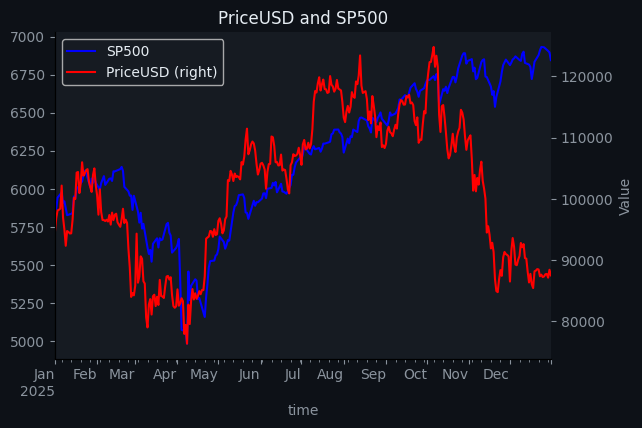

In [29]:
df_sp500_2025=df_sp500[df_sp500.index.year == 2025]
ax=df_sp500_2025.plot(y='Close', label='SP500', color='blue')
df_btc_2025.plot(y='PriceUSD', label='PriceUSD', color='red', ax=ax, secondary_y=True)
plt.title('PriceUSD and SP500')
plt.xlabel('Index')
plt.ylabel('Value')
#plt.legend()
plt.show()

Compute the correlation value for SP500 close vs PriceUSD. There seems to be significant correlation.

In [30]:
df_2 = pd.merge(df_sp500_2025, df_btc_2025,left_index=True, right_index=True)
correlation_value = df_2['PriceUSD'].corr(df_2['Close'])
correlation_value

np.float64(0.4255927497098442)

# Analysis based on Polymarket data and BTC data

In [31]:

#Use load_polymarket_data from prelude_template
from template.prelude_template import load_polymarket_data

polymarket_data = load_polymarket_data()
print('keys',polymarket_data.keys())

df_markets=polymarket_data["markets"]
df_politics_tokens=polymarket_data["tokens"]
df_politics_trades=polymarket_data["trades"]
df_finance_politics_odds_history=polymarket_data["odds_history"]
df_finance_politics_event_stats =polymarket_data["event_stats"]




2026-04-15 20:39:09 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-15 20:39:10 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-15 20:39:10 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-15 20:39:10 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-15 20:39:10 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-15 20:41:19 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-15 20:41:43 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-04-15 20:41:43 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-04-15 20:41:45 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-15 20:41:45 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-04-15 20:41:45 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-04-15 20:41:45 INFO       Loaded 440

keys dict_keys(['markets', 'tokens', 'trades', 'odds_history', 'event_stats', 'summary'])


Get only data related to Bitcoin and crypto.

In [32]:
df_markets_btc = df_markets[df_markets["question"].str.contains("Bitcoin|BTC|btc", case=False, na=False) | df_markets["category"].str.contains("Crypto", case=False, na=False)]
#df_markets_btc

Get Bitcoin related trades from Polymarket data. We filter trades which have positive outcomes.

In [33]:
trade1=pd.merge(df_politics_trades, df_markets_btc, on='market_id', how='inner')
trade1=pd.merge(trade1, df_politics_tokens, on=['market_id', 'token_id'], how='inner')
trade1['trade_date'] = trade1['timestamp'].dt.strftime('%Y-%m-%d')
trade1['trade_date'] = pd.to_datetime(trade1['trade_date'])
trade1['expected_size'] = trade1['size']*trade1['price']

allowed_outcomes = ['Up','Yes','Positive']
trade1=trade1[trade1['outcome'].isin(allowed_outcomes)]

Analyze for the year 2025. By aggregating trades for a given date.
<br>
Price is some sort of probability. Price*TradeQty is some sort of expectation. 

In [34]:
year=2025


trades_yyyy = trade1[trade1['timestamp'].dt.year == year]
sell_trades_yyyy = trades_yyyy[trades_yyyy['side'] == 'SELL']
buy_trades_yyyy = trades_yyyy[trades_yyyy['side'] == 'BUY']
trades_yyyy_group_by_date = trades_yyyy.groupby('trade_date')[['price']].mean()
buy_trades_yyyy_group_by_date = buy_trades_yyyy.groupby('trade_date')[['price']].mean()
sell_trades_yyyy_group_by_date = sell_trades_yyyy.groupby('trade_date')[['price']].mean()

expected_size_buy_trades_yyyy_group_by_date = buy_trades_yyyy.groupby('trade_date')[['expected_size']].sum()
expected_size_sell_trades_yyyy_group_by_date = sell_trades_yyyy.groupby('trade_date')[['expected_size']].sum()

buy_trades_summary_yyyy = buy_trades_yyyy.groupby('trade_date').agg({
    'expected_size': ['sum'],
    'price': 'mean',
    'size': 'sum'
})

sell_trades_summary_yyyy = sell_trades_yyyy.groupby('trade_date').agg({
    'expected_size': ['sum'],
    'price': 'mean',
    'size': 'sum'
})

trades_summary_yyyy=pd.merge(buy_trades_summary_yyyy, sell_trades_summary_yyyy, left_index=True, right_index=True)

trades_summary_yyyy.rename(columns={"expected_size_x":"expected_buy_size","price_x":"buy_price","size_x":"buy_size",
                                                          "expected_size_y":"expected_sell_size","price_y":"sell_price","size_y":"sell_size"},inplace=True)

trades_summary_yyyy_flat = pd.DataFrame({
    'expected_buy_size': trades_summary_yyyy['expected_buy_size']['sum'],
    'buy_price': trades_summary_yyyy['buy_price']['mean'],
    'buy_size': trades_summary_yyyy['buy_size']['sum'],
    'expected_sell_size': trades_summary_yyyy['expected_sell_size']['sum'],
    'sell_price': trades_summary_yyyy['sell_price']['mean'],
    'sell_size': trades_summary_yyyy['sell_size']['sum'],
    
})

trades_summary_yyyy_flat.head(4)

,expected_buy_size,buy_price,buy_size,expected_sell_size,sell_price,sell_size
trade_date,,,,,,
2025-04-07,220325.605189,0.271352,6.956831e+05,111851.977980,0.344353,407463.272315
2025-04-08,120773.087787,0.262969,4.973372e+05,54387.961612,0.274101,258067.768607
2025-04-09,324275.806554,0.260437,1.266823e+06,114820.413700,0.282044,491704.704887
2025-04-10,206190.231106,0.188307,1.063212e+06,68595.086775,0.185466,428393.738190


Plot of avg buy price vs sell price. If the buy price is above sell price, it indicates there is more buying for positive outcomes in polymarket data.

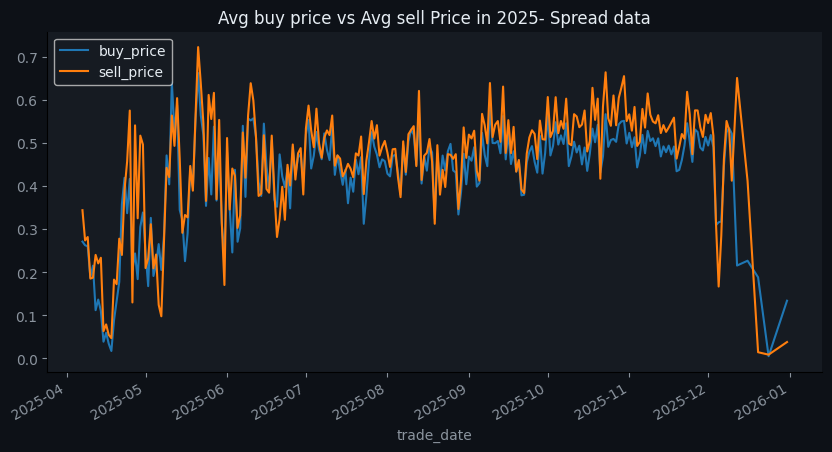

In [35]:
fig, ax = plt.subplots(figsize=(10, 5)) 
trades_summary_yyyy_flat.plot(ax=ax, y="buy_price", label="buy_price")
trades_summary_yyyy_flat.plot(ax=ax, y="sell_price", label="sell_price")

ax.set_title('Avg buy price vs Avg sell Price in 2025- Spread data')
plt.legend()
plt.show()

Check if there is any trend in buy_price vs sell_price. The data shows it is stationary.

In [36]:
check_stationarity(trades_summary_yyyy_flat['buy_price'] - trades_summary_yyyy_flat['sell_price'])

ADF Statistic: -4.491379
p-value: 0.000204
Critical Values:
	1%: -3.457
	5%: -2.873
	10%: -2.573
Stationary


Plot the expected trade size for buy vs sell. This is sort of proxy for market value

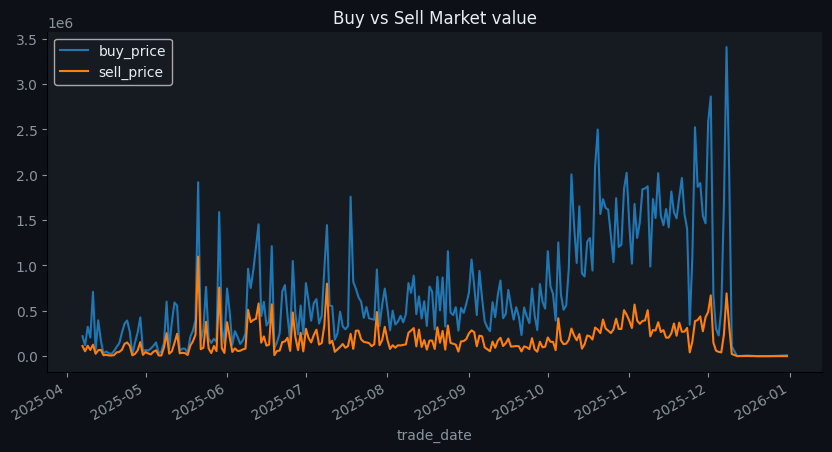

In [37]:
fig, ax = plt.subplots(figsize=(10, 5)) 
trades_summary_yyyy_flat.plot(ax=ax, y="expected_buy_size", label="buy_price")
trades_summary_yyyy_flat.plot(ax=ax, y="expected_sell_size", label="sell_price")

ax.set_title('Buy vs Sell Market value')
plt.legend()
plt.show()

We see there is a trend in the market size. The buy trades are increasing showing a trend.

In [38]:
check_stationarity(trades_summary_yyyy_flat['expected_buy_size'] - trades_summary_yyyy_flat['expected_sell_size'])

ADF Statistic: -1.601860
p-value: 0.482659
Critical Values:
	1%: -3.458
	5%: -2.874
	10%: -2.573
Non-stationary


Decompose this into patterns, which detects a clear trend.

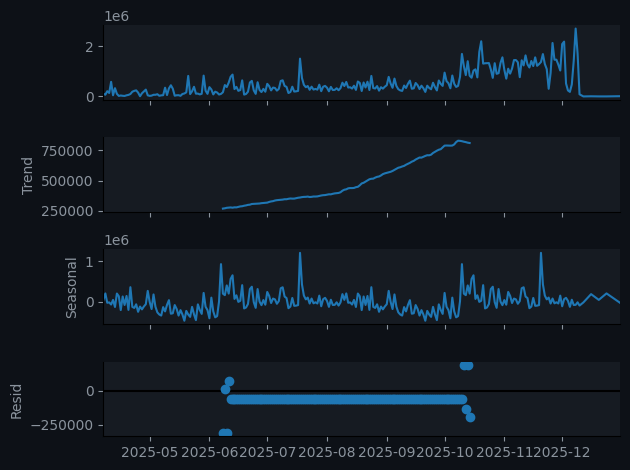

In [39]:
px=trades_summary_yyyy_flat['expected_buy_size'] - trades_summary_yyyy_flat['expected_sell_size']
result = seasonal_decompose(px, model='additive', period=125)  # Adjust period based on your data

trend = result.trend
seasonal = result.seasonal
residual = result.resid

decomposition_results = {
    'Close': {
        'trend': trend,
        'seasonal': seasonal,
        'residual': residual
    }
}

# Plot the decomposition
result.plot()
plt.tight_layout()
plt.show()

<b>Analyze the polymarkets odds data</b>

In [40]:
year=2025
df_finance_politics_odds_history["time"] = pd.to_datetime(df_finance_politics_odds_history["timestamp"])
df_finance_politics_odds_history=pd.merge(df_finance_politics_odds_history, df_politics_tokens, on=['market_id', 'token_id'], how='inner')
df_finance_politics_odds_history=pd.merge(df_finance_politics_odds_history, df_markets_btc, on='market_id', how='inner')
allowed_outcomes = ['Up','Yes','Positive']
df_finance_politics_odds_history=df_finance_politics_odds_history[df_finance_politics_odds_history['outcome'].isin(allowed_outcomes)]
df_finance_politics_odds_history['date'] = df_finance_politics_odds_history['timestamp'].dt.date
df_finance_politics_odds_history=df_finance_politics_odds_history.groupby(['date'])['price'].mean().to_frame()
df_finance_politics_odds_history.index = pd.to_datetime(df_finance_politics_odds_history.index)
df_finance_politics_odds_history_yyyy = df_finance_politics_odds_history[df_finance_politics_odds_history.index.year == year]

Join the trades data with odds history 

In [41]:
df_2=pd.merge(trades_summary_yyyy_flat, df_finance_politics_odds_history_yyyy,left_index=True, right_index=True)
correlation_value = df_2['buy_price'].corr(df_2['price'])
correlation_value

np.float64(0.566413068374056)

#### We see there is a correlation between Price (from polymarket data) and price (from Odds history)

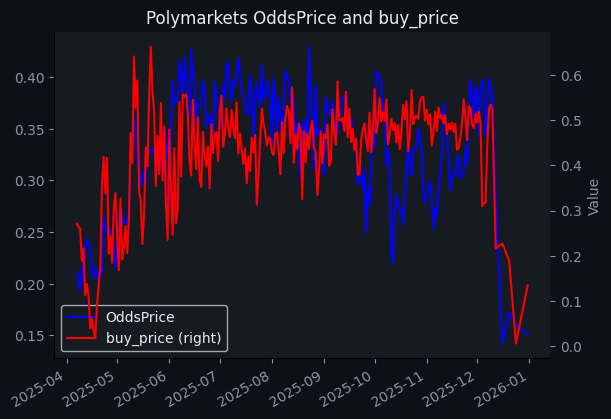

In [42]:
ax = df_2.plot(y='price', label='OddsPrice', color='blue')
df_2.plot(y='buy_price', label='buy_price', color='red', ax=ax, secondary_y=True)

plt.title('Polymarkets OddsPrice and buy_price')
plt.xlabel('Date')
plt.ylabel('Value')

plt.show()

We try to determine if Odds price has a causality to buy_price. The p_values have a less than 0.05 and hence null hypothesis that there is no causality can be rejected.

In [43]:
merged_df=df_2[['buy_price', 'price']]
gc_res = grangercausalitytests(merged_df, 40)
gc_res


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=17.5545 , p=0.0000  , df_denom=249, df_num=1
ssr based chi2 test:   chi2=17.7660 , p=0.0000  , df=1
likelihood ratio test: chi2=17.1677 , p=0.0000  , df=1
parameter F test:         F=17.5545 , p=0.0000  , df_denom=249, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.5688  , p=0.0113  , df_denom=246, df_num=2
ssr based chi2 test:   chi2=9.3233  , p=0.0095  , df=2
likelihood ratio test: chi2=9.1543  , p=0.0103  , df=2
parameter F test:         F=4.5688  , p=0.0113  , df_denom=246, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.8391  , p=0.0027  , df_denom=243, df_num=3
ssr based chi2 test:   chi2=14.9355 , p=0.0019  , df=3
likelihood ratio test: chi2=14.5064 , p=0.0023  , df=3
parameter F test:         F=4.8391  , p=0.0027  , df_denom=243, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.8424  , p=0.0249  

{np.int64(1): ({'ssr_ftest': (np.float64(17.554461074152236),
    np.float64(3.8794810383727816e-05),
    np.float64(249.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(17.765960605166118),
    np.float64(2.498129035461552e-05),
    np.int64(1)),
   'lrtest': (np.float64(17.167672119587223),
    np.float64(3.422107949428401e-05),
    np.int64(1)),
   'params_ftest': (np.float64(17.554461074152247),
    np.float64(3.8794810383727816e-05),
    np.float64(249.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.568780359004654),
    np.float64(0.011265931023983357),
    np.float64(246.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(9.323283496830637),
    np.float64(0.009450933602742137),
    np.int64(2)),
   'lrtest': (np.float64(9.154300709891004),
    np.float64(0.010284160787822617),
    np.int64(2)),
   'params_ftest': (np.float64(4.568780359004677),
    np.float64(0.011265931023983029),
    np.float64(246.0),
    2.0)},
   array([[0., 0., 1

<b>buy_price and price seem to be cointegrated too.</b>

In [44]:
y0=np.log(df_2['buy_price'])
y1=np.log(df_2['price'])
y0=df_2['buy_price']
y1=df_2['price']

coint_t_statistic, p_value, critical_values = ts.coint(y0, y1, trend='c')

print(f"Cointegration Test Statistic: {coint_t_statistic}")
print(f"P-value: {p_value}")
print(f"Critical Values (1%, 5%, 10%): {critical_values}")

if p_value < 0.05:
    print("Result: Series are likely cointegrated (reject H0)")
else:
    print("Result: Series are likely NOT cointegrated (fail to reject H0)")

Cointegration Test Statistic: -2.7758899440832625
P-value: 0.1734766475500356
Critical Values (1%, 5%, 10%): [-3.94042787 -3.36048387 -3.06132299]
Result: Series are likely NOT cointegrated (fail to reject H0)


# Analysis between BTC data and polymarket data.

Since price (from odds data) seems to have causality, we try to find relation between price and btc price.

In [45]:
df_2=pd.merge(df_2, df_btc_2025,left_index=True, right_index=True)
df_2.head(2)

,expected_buy_size,buy_price,buy_size,expected_sell_size,sell_price,sell_size,price,AdrActCnt,AdrBalCnt,AssetCompletionTime,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
2025-04-07,220325.605189,0.271352,695683.085655,111851.977980,0.344353,407463.272315,0.210328,791618.0,53314065.0,1.744079e+09,...,NaN,NaN,NaN,1.984798e+07,2.442926e+06,1.940216e+11,2.079455e+07,315963.0,736035.0,3.254599e+10
2025-04-08,120773.087787,0.262969,497337.224191,54387.961612,0.274101,258067.768607,0.200775,736263.0,53345480.0,1.744166e+09,...,NaN,NaN,NaN,1.984845e+07,2.449404e+06,1.870155e+11,2.079467e+07,360926.0,806113.0,1.752911e+10


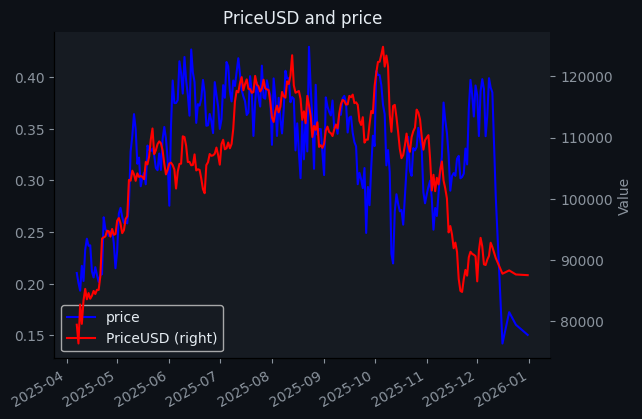

In [46]:
ax = df_2.plot(y='price', label='price', color='blue')
df_2.plot(y='PriceUSD', label='PriceUSD', color='red', ax=ax, secondary_y=True)

plt.title('PriceUSD and price')
plt.xlabel('Date')
plt.ylabel('Value')

plt.show()




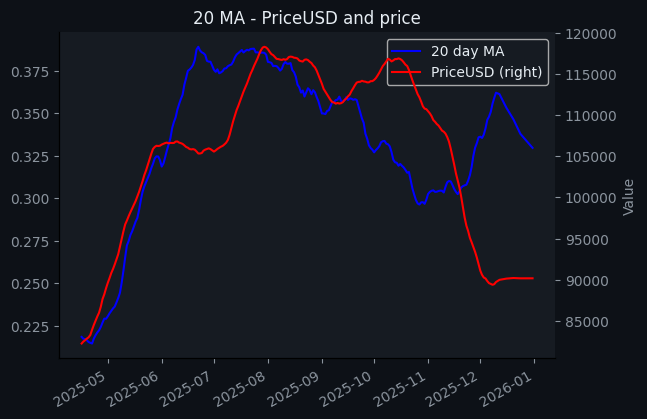

In [47]:
ma = df_2['price'].rolling(20, min_periods=20 // 2).mean().dropna().to_frame() #OK
ma_btc = df_2['PriceUSD'].rolling(20, min_periods=20 // 2).mean().dropna().to_frame()

ax = ma.plot(y='price', label='20 day MA', color='blue')
ma_btc.plot(y='PriceUSD', label='PriceUSD', color='red', ax=ax, secondary_y=True)

plt.title('20 MA - PriceUSD and price')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

From the graph, it looks like the BTC MA of PriceUSD seems to be following Price (Odds probability). We compute correlation.

In [48]:
ma_btc['PriceUSD'].corr(ma['price'])

np.float64(0.6478035758595156)

## Use the code provided by Trilemma, which enriches BTC Data.
<b>We need the 'example_1' folder to be in path</b>

In [49]:


if (cwd / "example_1" / "model_development_example_1.py").exists():
#    #sys.path.insert(0, str(cwd))
    from example_1.model_development_example_1 import *

#from template.model_development_template import precompute_features

In [50]:
df_btc['PriceUSD_coinmetrics'] = df_btc['PriceUSD']
df_btc_with_features = precompute_features(df_btc)

2026-04-15 20:44:08 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-15 20:44:09 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-15 20:44:09 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-15 20:44:09 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-15 20:44:09 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-15 20:46:13 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-15 20:46:37 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-04-15 20:46:37 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-04-15 20:46:39 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-15 20:46:39 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-04-15 20:46:39 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-04-15 20:46:39 INFO       Loaded 440

In [51]:
df_btc_with_features.corr()

,PriceUSD_coinmetrics,price_ma,price_vs_ma,mvrv_zscore,mvrv_gradient,mvrv_acceleration,mvrv_zone,mvrv_volatility,signal_confidence,polymarket_sentiment
PriceUSD_coinmetrics,1.000000,0.966435,-0.064248,-0.002122,-0.119277,-0.022063,-0.034631,-0.061100,0.172224,0.038066
price_ma,0.966435,1.000000,-0.187190,-0.145521,-0.159968,-0.013665,-0.170266,-0.096818,0.200753,0.041483
price_vs_ma,-0.064248,-0.187190,1.000000,0.678629,0.134386,-0.055306,0.642606,0.392189,-0.458385,-0.000590
mvrv_zscore,-0.002122,-0.145521,0.678629,1.000000,0.373105,0.060575,0.896778,0.332178,0.066408,-0.006009
mvrv_gradient,-0.119277,-0.159968,0.134386,0.373105,1.000000,0.550891,0.421557,-0.007534,0.238595,0.021112
mvrv_acceleration,-0.022063,-0.013665,-0.055306,0.060575,0.550891,1.000000,0.075221,-0.087699,0.157396,-0.000765
mvrv_zone,-0.034631,-0.170266,0.642606,0.896778,0.421557,0.075221,1.000000,0.267656,0.055980,0.007530
mvrv_volatility,-0.061100,-0.096818,0.392189,0.332178,-0.007534,-0.087699,0.267656,1.000000,-0.049916,-0.031820
signal_confidence,0.172224,0.200753,-0.458385,0.066408,0.238595,0.157396,0.055980,-0.049916,1.000000,0.012627
polymarket_sentiment,0.038066,0.041483,-0.000590,-0.006009,0.021112,-0.000765,0.007530,-0.031820,0.012627,1.000000


PriceUSD has a high correlation with Price_ma and signal_confidence. It also have correlation with polymarket_sentiment.

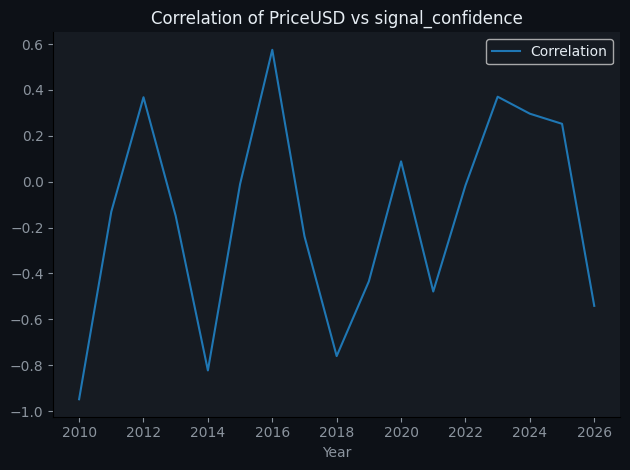

In [52]:
tmp=[]
years=[]
correlation_cols=["PriceUSD_coinmetrics","signal_confidence","polymarket_sentiment"]
for year in df_btc_with_features.index.year.unique():

    df_btc_with_features_year=df_btc_with_features[df_btc_with_features.index.year == year]
    correlation_matrix = df_btc_with_features_year[correlation_cols].corr()
    tmp.append(correlation_matrix["PriceUSD_coinmetrics"]["signal_confidence"])
    years.append(year)

my_dict = {
    'Year': years,
    'Correlation': tmp
}

# Create the DataFrame

df_2d = pd.DataFrame(my_dict)
df_2d.set_index('Year', inplace=True)

df_2d.plot()
plt.title('Correlation of PriceUSD vs signal_confidence')
plt.tight_layout()
plt.show()

We see that correlation is not consistent, it keeps changing every year. 
<br>
Also it seems to change direction. From the graph we see that this seems to have a period of 4 years.

There is no granger causality due to signal_confidence, but there is a granger causality due to polymarket_sentiment.

In [53]:
ts_df = pd.DataFrame(columns=['PriceUSD_coinmetrics', 'polymarket_sentiment'], data=zip(df_btc_with_features['PriceUSD_coinmetrics'],df_btc_with_features['polymarket_sentiment']))
gc_res = grangercausalitytests(ts_df, 20)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7099  , p=0.3995  , df_denom=5656, df_num=1
ssr based chi2 test:   chi2=0.7103  , p=0.3993  , df=1
likelihood ratio test: chi2=0.7103  , p=0.3994  , df=1
parameter F test:         F=0.7099  , p=0.3995  , df_denom=5656, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.9640  , p=0.0190  , df_denom=5653, df_num=2
ssr based chi2 test:   chi2=7.9350  , p=0.0189  , df=2
likelihood ratio test: chi2=7.9295  , p=0.0190  , df=2
parameter F test:         F=3.9640  , p=0.0190  , df_denom=5653, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.9428  , p=0.0317  , df_denom=5650, df_num=3
ssr based chi2 test:   chi2=8.8394  , p=0.0315  , df=3
likelihood ratio test: chi2=8.8325  , p=0.0316  , df=3
parameter F test:         F=2.9428  , p=0.0317  , df_denom=5650, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.6642  , p=0.

In [54]:
#df_btc_with_features.index

In [55]:
year=2025
df_btc_with_features_yyyy=df_btc_with_features[df_btc_with_features.index.year == year]
#df_btc_with_features_yyyy.head(2)
df_2=pd.merge(df_2, df_btc_with_features_yyyy,left_index=True, right_index=True)
df_2.head(2)

,expected_buy_size,buy_price,buy_size,expected_sell_size,sell_price,sell_size,price,AdrActCnt,AdrBalCnt,AssetCompletionTime,...,PriceUSD_coinmetrics,price_ma,price_vs_ma,mvrv_zscore,mvrv_gradient,mvrv_acceleration,mvrv_zone,mvrv_volatility,signal_confidence,polymarket_sentiment
2025-04-07,220325.605189,0.271352,695683.085655,111851.977980,0.344353,407463.272315,0.210328,791618.0,53314065.0,1.744079e+09,...,79421.804411,86807.713708,-0.101198,-1.619645,-0.875808,0.180656,-1.0,0.788301,0.893700,0.500000
2025-04-08,120773.087787,0.262969,497337.224191,54387.961612,0.274101,258067.768607,0.200775,736263.0,53345480.0,1.744166e+09,...,76351.429530,86873.701097,-0.085084,-1.473095,-0.871339,0.196958,-1.0,0.802228,0.900883,0.637931


Analyze correlation between Odds/Price and signal_confidence.

In [56]:
correlation_coefficient = df_2['price'].corr(df_2['signal_confidence'])
correlation_coefficient


np.float64(0.1521395579006871)

Compute the correlation between the entire dataframe.

In [57]:
x=df_2.corr()["PriceUSD_coinmetrics"].to_dict()
sorted_dict_desc = {k: v for k, v in sorted(x.items(), key=lambda item: item[1], reverse=True)}


In [58]:
sorted_dict_desc

{'IssTotUSD': 0.778676969908218,
 'PriceBTC': nan,
 'PriceUSD': 1.0,
 'ReferenceRate': nan,
 'ReferenceRateETH': nan,
 'ReferenceRateEUR': nan,
 'ReferenceRateUSD': nan,
 'PriceUSD_coinmetrics': 1.0,
 'CapMrktEstUSD': 0.9998857377092571,
 'CapMrktCurUSD': 0.9998853957969399,
 'SplyExUSD': 0.966253684549396,
 'ROI1yr': 0.8684895382684061,
 'price_vs_ma': 0.8115872730792291,
 'CapMVRVCur': 0.7239287710660492,
 'SplyExNtv': 0.6350326042587162,
 'mvrv_zscore': 0.6270703233256757,
 'mvrv_zone': 0.6002495184553994,
 'price': 0.5578409327447137,
 'buy_price': 0.5376153748381559,
 'sell_price': 0.4685514689445368,
 'ROI30d': 0.33033921593627247,
 'signal_confidence': 0.25542001614033916,
 'FlowOutExUSD': 0.2516238889227474,
 'FlowInExUSD': 0.24900851766720222,
 'mvrv_gradient': 0.2160323651406943,
 'price_ma': 0.14489452925820007,
 'TxCnt': 0.14276176170031396,
 'IssTotNtv': 0.11584023243122551,
 'BlkCnt': 0.1158402324312252,
 'AdrActCnt': 0.1130782481145067,
 'polymarket_sentiment': 0.0991591

Based on the correlation data of PriceUSD_coinmetrics with other attributes, we can further analyze based on the highest correlations.

<html>
<table>
  <caption><b>Correlation data of PriceUSD_coinmetrics with other attributes</b></caption>
  <thead>
    <tr>
      <th>Attribute</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>IssTotUSD</td>
      <td>0.778676969908218</td>
    </tr>
    <tr>
      <td>SplyExUSD</td>
      <td>0.966253684549396</td>
    </tr> 
    <tr>
      <td>ROI1yr</td>
      <td>0.8684895382684061</td>
    </tr> 
    <tr>
      <td>SplyExNtv</td>
      <td>0.6350326042587162</td>
    </tr> 
    <tr>
      <td>mvrv_zscore</td>
      <td>0.6270703233256757</td>
    </tr>     
    <tr>
      <td>mvrv_zone</td>
      <td>0.6002495184553994</td>
    </tr>     
    <tr>
      <td>price</td>
      <td>0.5578409327447137</td>
    </tr>     
    <tr>
      <td>buy_price</td>
      <td>0.5376153748381559</td>
    </tr>     
    <tr>
      <td>sell_price</td>
      <td>0.4685514689445368</td>
    </tr>     
    <tr>
      <td>ROI30d</td>
      <td>0.33033921593627247</td>
    </tr>  
    <tr>
      <td>signal_confidence</td>
      <td>0.25542001614033916</td>
    </tr>  
  </tbody>
</table>
</html>

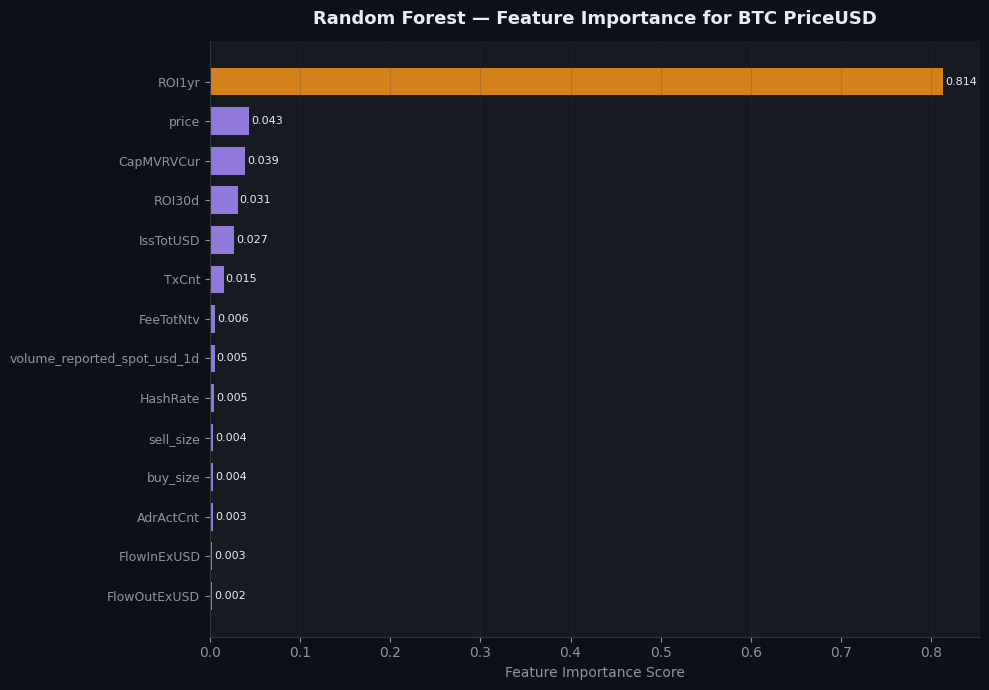


Model R² on training data: 0.9911

Top 5 most important features:
IssTotUSD     0.026862
ROI30d        0.030553
CapMVRVCur    0.038946
price         0.043387
ROI1yr        0.813568


In [59]:
FEATURE_COLS = [
    'CapMVRVCur', 'ROI1yr', 'ROI30d', 'AdrActCnt', 'TxCnt',
    'HashRate', 'FlowInExUSD', 'FlowOutExUSD', 'IssTotUSD',
    'volume_reported_spot_usd_1d', 'FeeTotNtv',
    'price', 'buy_size', 'sell_size'
]

train_df = df_2[FEATURE_COLS + ['PriceUSD']].dropna()
X, y = train_df[FEATURE_COLS], train_df['PriceUSD']

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('#161b22')
fig.patch.set_facecolor('#0d1117')

colors = [BTC if v > 0.05 else PURP for v in importances.values]
ax.barh(range(len(importances)), importances.values, color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index, fontsize=9)
ax.set_xlabel('Feature Importance Score', color='#8b949e')
ax.set_title('Random Forest — Feature Importance for BTC PriceUSD', fontsize=13, fontweight='bold', color='#e6edf3', pad=12)
for spine in ax.spines.values(): spine.set_color('#30363d')
ax.grid(True, alpha=0.2, axis='x')

for i, val in enumerate(importances.values):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8, color='#e6edf3')

plt.tight_layout()
plt.show()

print(f'\nModel R² on training data: {rf.score(X, y):.4f}')
print('\nTop 5 most important features:')
print(importances.tail(5).to_string())

# Fear and Greed Index Exploration



The **Crypto Fear and Greed Index (FGI)**, developed by Alternative.me, is a composite sentiment metric that measures the prevailing psychological state of the market on a scale from 0 to 100. Rather than looking strictly at price, the index calculates a "magic number" by aggregating six distinct quantitative and qualitative indicators:
* **Volatility (25%):** Current price swings compared to 30- and 90-day averages.
* **Market Momentum & Volume (25%):** Current buying/selling volume against 30- and 90-day trends.
* **Social Media (15%):** Interaction rates, hashtags, and public interest on platforms like Twitter.
* **Surveys (15%):** Weekly polling of individual investor outlooks.
* **Bitcoin Dominance (10%):** BTC's market cap share relative to speculative altcoins.
* **Search Trends (10%):** Google search volumes for specific Bitcoin-related queries.

### Why is it relevant?
In a Bitcoin accumulation model, market psychology is just as critical as raw price action. By quantifying human emotion, the FGI acts as a powerful **contrarian indicator**:
* **Extreme Fear (0-24):** Indicates investors are overly bearish. This often correlates with market capitulation, potential undervaluation, and an optimal time to increase accumulation (buy the dip).
* **Extreme Greed (76-100):** Indicates investors are overly bullish. This signals market froth, overvaluation, and an optimal time to decrease accumulation or begin distribution (taking profits).

### What are we trying to do?
In this section, we will load the historical FGI dataset from our local data/ folder, merge it with our Bitcoin price history, and rigorously backtest its relationship against future price momentum. Our goal is to determine if these sentiment extremes can serve as reliable algorithmic triggers to optimize when we buy and when we sell.

<b>Key Schema Columns:</b>
- timestamp / date: The date of the sentiment reading (ranging from 2018 to 2024)
- fgi_value: An integer score ranging from 0 to 100.
- value_classification: A categorical text label that maps directly to the score:
    - 0 - 24: Extreme Fear (Market is oversold)
    - 25 - 49: Fear
    - 50: Neutral
    - 51 - 74: Greed
    - 75 - 100: Extreme Greed (Market needs a correction)

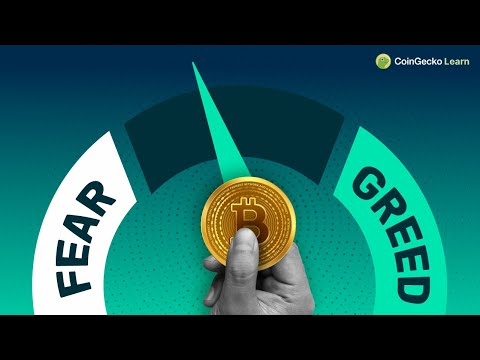

In [60]:
## Here is just a short introduction of what FGI is.

from IPython.display import YouTubeVideo
YouTubeVideo("xwv0abKb2h8", width=600, height=300)

In [61]:
#pip install -r requirements.txt

In [62]:
btc_df = load_bitcoin_data(COINMETRICS_PATH)
if btc_df is not None:
    display(btc_df.head())
    print("Shape:", btc_df.shape)

Loading Bitcoin data from C:\Users\bpree\eda\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 3.60 GB
[Memory] After loading Bitcoin data: 3.62 GB (Δ 15.38 MB)
Successfully loaded 6221 rows.


time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null


Shape: (6221, 32)


In [63]:
import pandas as pd
from pathlib import Path

# Dynamically route the path based on the notebook's current working directory
current_dir = Path.cwd()

# Check if 'data' is in the current directory (if notebook is in repo root)
# Or if it's one level up (if notebook is inside a 'notebooks' subfolder)
if (current_dir / "data").exists():
    data_dir = current_dir / "data"
else:
    data_dir = current_dir.parent / "data"

# Construct the OS-agnostic path to the CSV file
file_path = data_dir / "crypto_fear_and_greed_index_2018_2024.csv"


print(f"Attempting to load FGI data from: {file_path}")

if file_path.exists():
    # Load the CSV into a pandas DataFrame
    fgi_df = pd.read_csv(file_path)
    
    # Ensure the 'date' column is correctly parsed as a date object for merging later
    fgi_df['date'] = pd.to_datetime(fgi_df['date']).dt.date
    
    print(f" Successfully loaded {len(fgi_df)} records.")
    display(fgi_df.head())
else:
    print(f" File not found at: {file_path}")
    print("Please ensure the data file exists in the repository's 'data' folder.")

Attempting to load FGI data from: C:\Users\bpree\eda\data\crypto_fear_and_greed_index_2018_2024.csv
 Successfully loaded 2522 records.


,date,value,value_classification
0,2018-02-01,30.0,Fear
1,2018-02-02,15.0,Extreme Fear
2,2018-02-03,40.0,Fear
3,2018-02-04,24.0,Extreme Fear
4,2018-02-05,11.0,Extreme Fear


Merging Fear and Greed Index with Bitcoin price data...

Pearson Correlation between FGI and Bitcoin PriceUSD: 0.4237


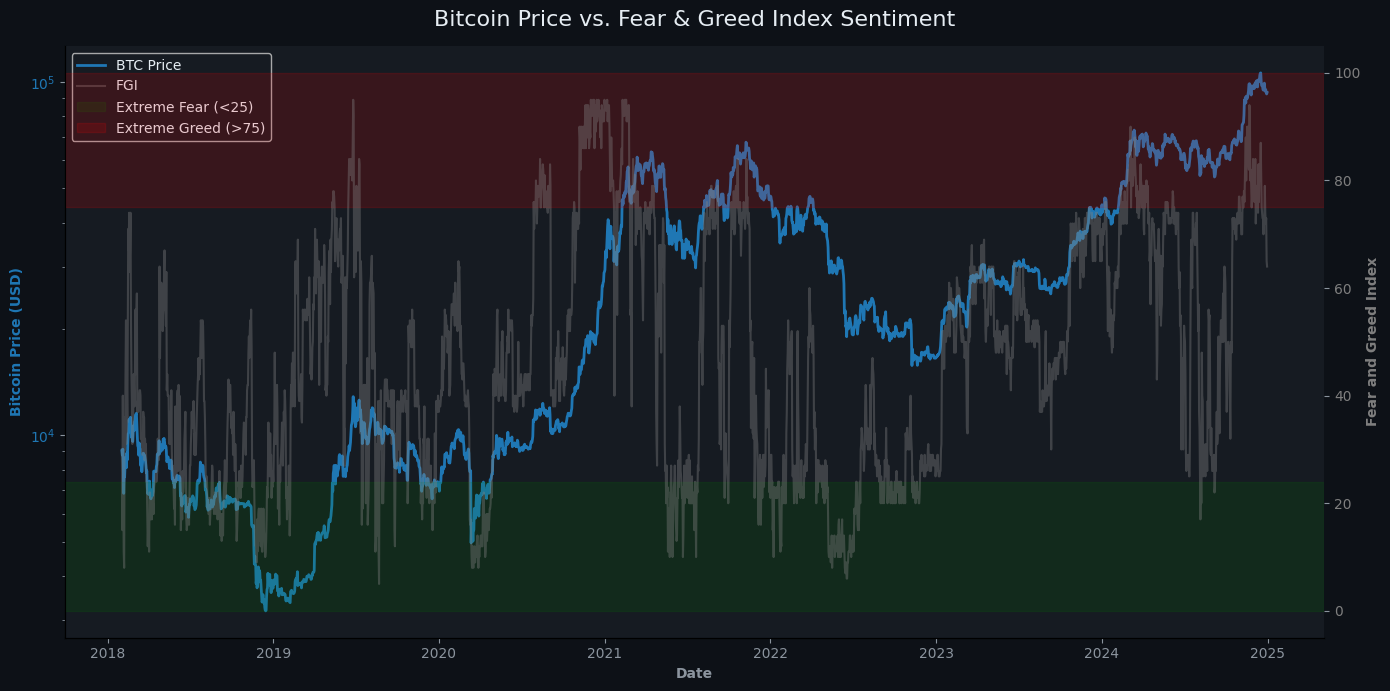

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

# Ensure `btc_df` from earlier in the notebook and `fgi_df` exist
if 'btc_df' in locals() and btc_df is not None and 'fgi_df' in locals():
    print("Merging Fear and Greed Index with Bitcoin price data...")
    
    # 1. Convert pandas fgi_df to polars for joining
    fgi_pl = pl.from_pandas(fgi_df)
    
    # 2. Extract date from btc_df for merging
    if "date" not in btc_df.columns:
        btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
    else:
        btc_date_df = btc_df
        
    # 3. Join FGI to BTC price on 'date'
    merged_fgi_btc = btc_date_df.join(fgi_pl, on="date", how="inner").select(
        ["date", "PriceUSD", "value", "value_classification"]
    )
    
    # Convert back to pandas for matplotlib & seaborn plotting
    df_plot = merged_fgi_btc.to_pandas()
    df_plot['date'] = pd.to_datetime(df_plot['date'])
    df_plot = df_plot.dropna(subset=['PriceUSD', 'value'])

    # --- Correlation Analysis ---
    corr = df_plot['value'].corr(df_plot['PriceUSD'])
    print(f"\nPearson Correlation between FGI and Bitcoin PriceUSD: {corr:.4f}")
    
    # Plot 1: Time Series Overlay
    fig, ax1 = plt.subplots(figsize=(14, 7))

    color_price = 'tab:blue'
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('Bitcoin Price (USD)', color=color_price, fontweight='bold')
    ax1.plot(df_plot['date'], df_plot['PriceUSD'], color=color_price, label='BTC Price', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_price)
    # Log scale is often better for BTC price visualizations over long horizons
    ax1.set_yscale('log') 

    ax2 = ax1.twinx()  
    color_fgi = 'tab:gray'
    ax2.set_ylabel('Fear and Greed Index', color=color_fgi, fontweight='bold')  
    ax2.plot(df_plot['date'], df_plot['value'], color=color_fgi, alpha=0.4, label='FGI')
    ax2.tick_params(axis='y', labelcolor=color_fgi)

    # Add reference bands for extreme zones
    ax2.axhspan(0, 24, color='green', alpha=0.15, label='Extreme Fear (<25)')
    ax2.axhspan(75, 100, color='red', alpha=0.15, label='Extreme Greed (>75)')

    fig.suptitle('Bitcoin Price vs. Fear & Greed Index Sentiment', fontsize=16)
    fig.tight_layout()
    
    # Merge legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.show()

else:
    print(" FGI data or BTC data not found. Please ensure the preceding cells ran successfully.")

## FGI has 0.42 correlation to btc price, at least in this 2018-2024 window

### Correlating FGI to Price Velocity (ROI)

Correlating a bounded oscillator (0-100 FGI) with an unbounded exponentially growing asset (Bitcoin absolute price) is statistically noisy over long time horizons. Because the Fear and Greed Index is heavily influenced by momentum and volatility, it fundamentally measures the *velocity* and *acceleration* of the market.

In this section, we:
1. Manually compute short-term price velocity: **1-day, 3-day, and 7-day ROI**.
2. Utilize the existing **30-day ROI (`ROI30d`)** from the Coin Metrics dataset.
3. Evaluate how strongly the Fear and Greed Index correlates with these percentage changes compared to the raw `PriceUSD`.

In [65]:
# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute 1-day, 3-day, and 7-day ROI as percentage changes
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(1) - 1) * 100).alias("ROI1d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(3) - 1) * 100).alias("ROI3d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(7) - 1) * 100).alias("ROI7d")
])

print(" Computed ROI1d, ROI3d, and ROI7d columns.")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_velocity_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d", "value"]
    df_analysis = merged_velocity_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur on the first few days due to rolling window shifts)
    df_analysis = df_analysis.dropna()
    
    print(f" Successfully merged FGI with BTC velocity metrics. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(5))
else:
    print(" 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

 Computed ROI1d, ROI3d, and ROI7d columns.
 Successfully merged FGI with BTC velocity metrics. Analyzable records: 2522


,date,PriceUSD,ROI1d,ROI3d,ROI7d,ROI30d,value
0,2018-02-01,9039.865075,-10.051951,-18.797925,-18.782682,-38.730733,30.0
1,2018-02-02,8786.077380,-2.807428,-11.782357,-20.383907,-41.466290,15.0
2,2018-02-03,9132.100322,3.938310,-9.134196,-19.334649,-39.403331,40.0
3,2018-02-04,8250.526896,-9.653567,-8.731747,-28.972484,-51.459572,24.0
4,2018-02-05,6849.542559,-16.980544,-22.040949,-38.472857,-59.952601,11.0


--- Pearson Correlation with Fear and Greed Index (FGI) ---
ROI30d      0.716035
ROI7d       0.438480
PriceUSD    0.423708
ROI3d       0.267156
ROI1d       0.046601
------------------------------------------------------------


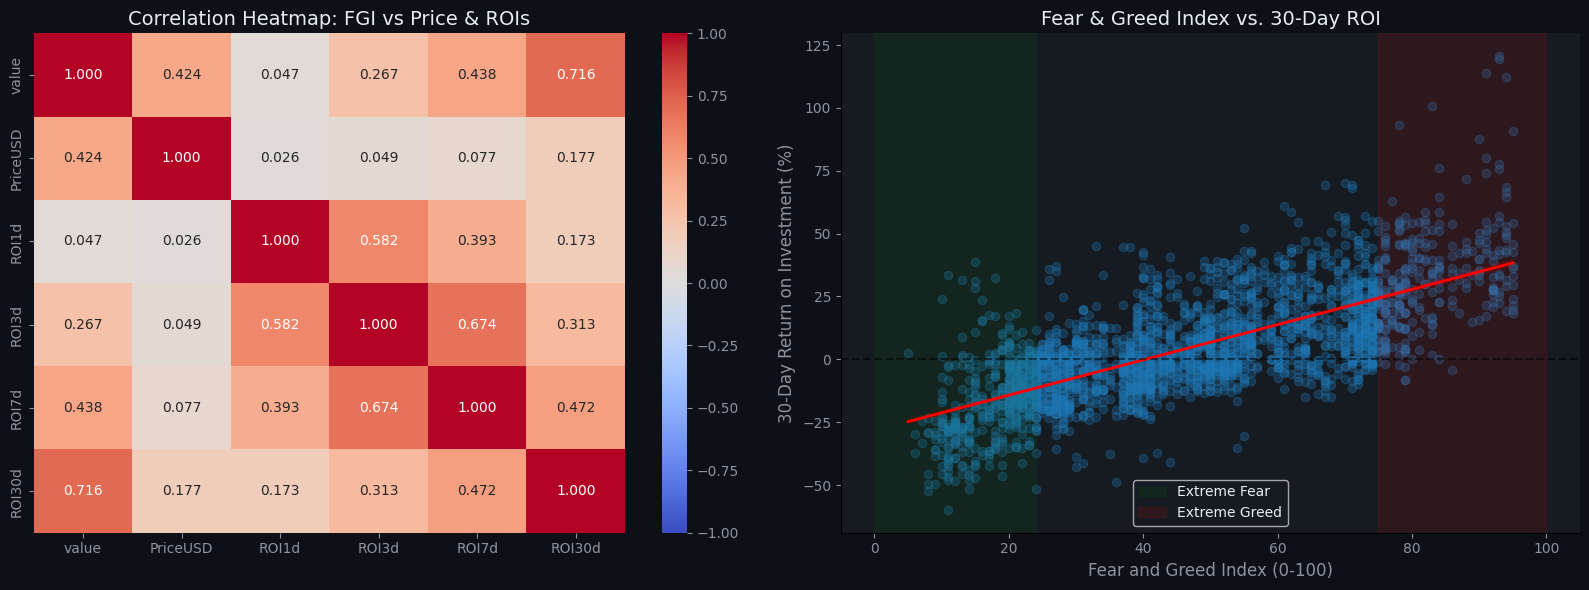

In [66]:
if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation with Fear and Greed Index (FGI) ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Price & ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs ROI30d (Regression Plot)
    # We use ROI30d or ROI7d here as they typically show strong behavioral trends
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. 30-Day ROI", fontsize=14)
    axes[1].set_xlabel("Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("30-Day Return on Investment (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

### FGI has a good correlation to ROI30d values because it captures investor sentiment. People feel 'greedier' when they are having good returns and 'more fearful' when not.
50% of the index's core mathematical weight is directly benchmarked against 30-day historical data, it is practically hardwired to correlate most strongly with the ROI30d metric.
* Volatility (25% weight): It compares Bitcoin's current volatility to its average volatility over the last 30 days and 90 days.
* Market Momentum/Volume (25% weight): It compares current trading volume and momentum against the 30-day and 90-day averages.

#### Moving forward, we’re more interested in using FGI as a forward‑looking tool. 
By mapping sentiment against future ROI, this parameter can guide a disciplined accumulation strategy, like supposedly buying more aggressively during fear phases and scaling back during greed, and helping smooth entry points and improve long‑term returns.

In [67]:
# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute FORWARD-looking 1-day, 3-day, 7-day, and 30-day ROI
# shift(-N) brings the price N days in the future to the current row
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-1) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI1d"),
    ((pl.col("PriceUSD").shift(-3) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI3d"),
    ((pl.col("PriceUSD").shift(-7) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI7d"),
    ((pl.col("PriceUSD").shift(-30) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI30d")
])

print(" Computed Forward ROIs (1d, 3d, 7d, 30d).")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_fwd_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d", "value"]
    df_analysis = merged_fwd_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur at the very END of the dataset due to forward shifts)
    df_analysis = df_analysis.dropna()
    
    print(f" Successfully merged FGI with Forward ROIs. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(5))
else:
    print(" 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

 Computed Forward ROIs (1d, 3d, 7d, 30d).
 Successfully merged FGI with Forward ROIs. Analyzable records: 2522


,date,PriceUSD,Fwd_ROI1d,Fwd_ROI3d,Fwd_ROI7d,Fwd_ROI30d,value
0,2018-02-01,9039.865075,-2.807428,-8.731747,-9.085138,26.392158,30.0
1,2018-02-02,8786.077380,3.938310,-22.040949,-1.429807,30.463035,15.0
2,2018-02-03,9132.100322,-9.653567,-15.258881,-6.590023,26.374677,40.0
3,2018-02-04,8250.526896,-16.980544,-7.586564,-1.864104,29.410344,24.0
4,2018-02-05,6849.542559,12.980449,19.987295,30.047665,44.580240,11.0


--- Pearson Correlation: Current FGI vs FORWARD Returns ---
PriceUSD      0.423708
Fwd_ROI30d    0.146626
Fwd_ROI7d     0.077552
Fwd_ROI3d     0.062701
Fwd_ROI1d     0.037707
------------------------------------------------------------


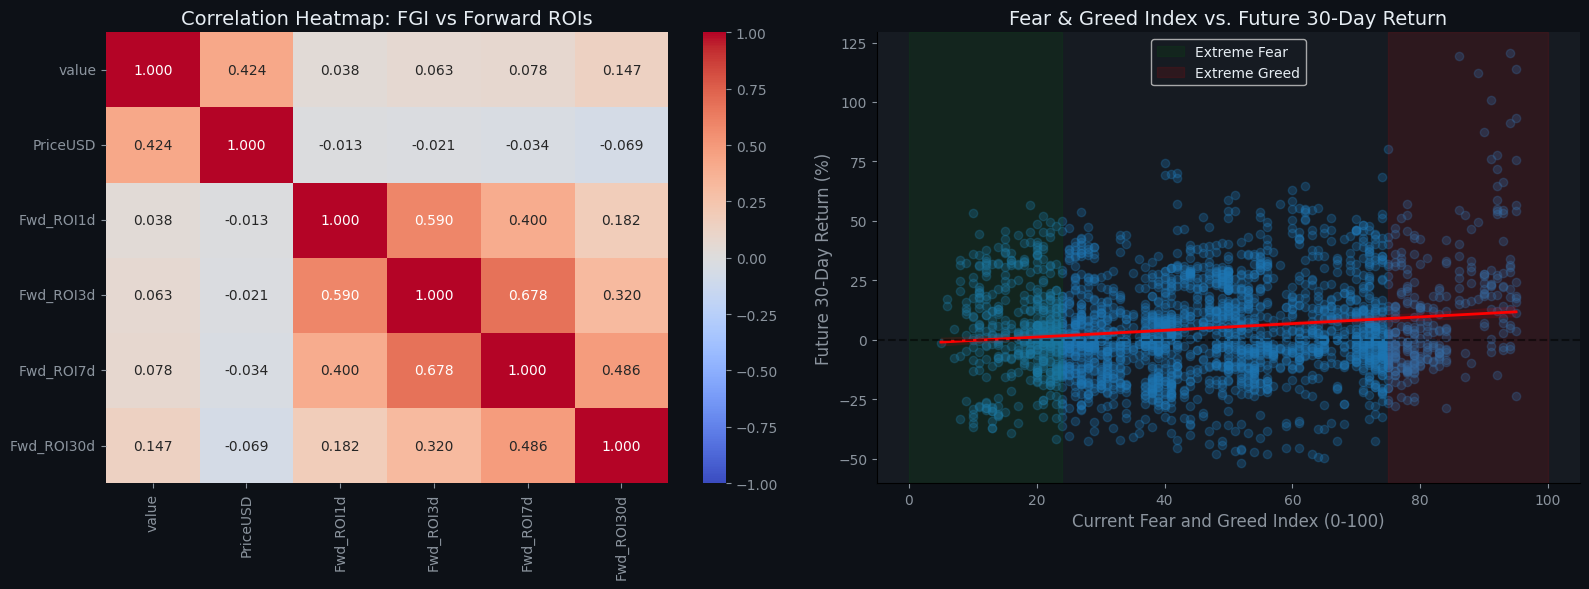

In [68]:
if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation: Current FGI vs FORWARD Returns ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Forward ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs Fwd_ROI30d
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="Fwd_ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. Future 30-Day Return", fontsize=14)
    axes[1].set_xlabel("Current Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("Future 30-Day Return (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## FORWARD ROI of 1 to 7 days seem to be not useful since the correlation is too low. Also, it might be better to separate the FGI to bins from extreme fear to extreme greed

### Interpreting Short-Term vs. Medium-Term Forward Returns

The correlation heatmap reveals a crucial dynamic about market sentiment and Bitcoin price action: **Short-term price velocity is mostly noise, but medium-term momentum is highly persistent.**

* **The Noise of the Micro-Trend (1d, 3d, 7d):** Forward returns under 7 days show almost zero correlation with the Fear and Greed Index. Sentiment is a macroeconomic indicator; it does not reliably predict day-to-day random walks or immediate price bounces.
* **The Momentum Engine (30d):** The 30-day forward return exhibits a positive relationship with sentiment. When the market enters "Greed," the trend tends to persist over the next month. Extreme euphoria rarely collapses instantly; it sustains itself, meaning a naive contrarian strategy (shorting the moment the market turns greedy) would result in missing significant upside momentum.

To build a robust accumulation model, we must expand our time horizon beyond 30 days. We need to identify the macroeconomic phase shifts—the points where accumulating capital is statistically safest, and the points where we should begin distributing (selling) our accumulated Bitcoin.

--- Average 30-Day Forward Return by FGI Bracket ---
                             mean    median  count
FGI_Bracket                                       
Extreme Fear (0-24)      3.767502  1.773568    497
Fear (25-45)             1.111344 -0.444955    758
Neutral (46-55)          5.829062  6.068682    387
Greed (56-75)            6.083721  1.587965    609
Extreme Greed (76-100)  13.773986  6.966540    271
------------------------------------------------------------


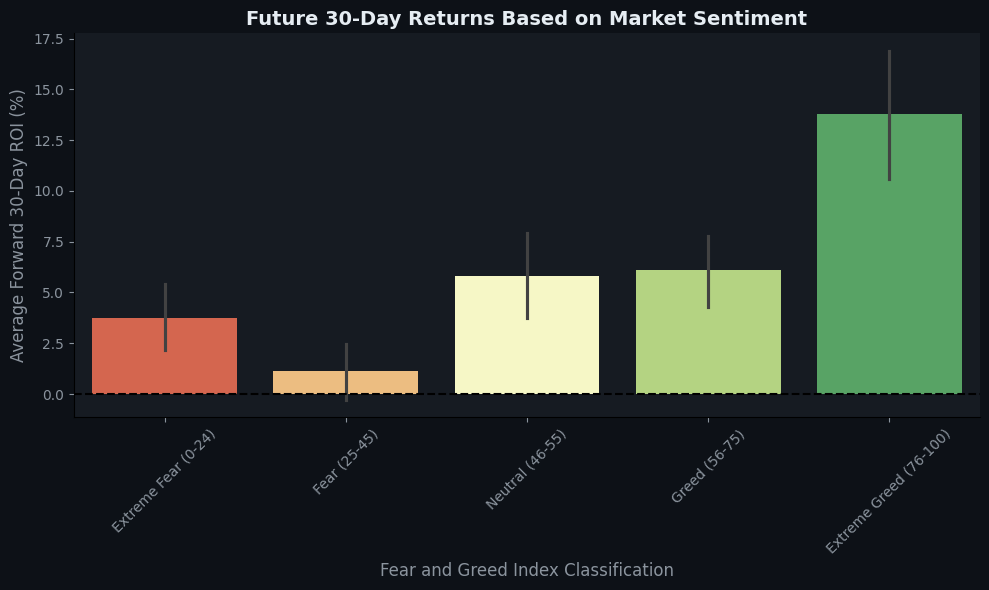

In [69]:
if 'df_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    # Typical CMC/Alternative.me classifications:
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_analysis['FGI_Bracket'] = pd.cut(df_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward 30-day return for each bracket
    fgi_grouped = df_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI30d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 30-Day Forward Return by FGI Bracket ---")
    print(fgi_grouped)
    print("-" * 60)
    
    # 3. Visualize the non-linear relationship
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # We use a barplot to show the mean return with error bars for variance
    sns.barplot(data=df_analysis, x='FGI_Bracket', y='Fwd_ROI30d', hue='FGI_Bracket', ax=ax, palette='RdYlGn')
    
    ax.set_title("Future 30-Day Returns Based on Market Sentiment", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward 30-Day ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--')
    
    # Rotate x-axis labels if they overlap
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Over a 30 day timeframe, **Extreme Greed** has the highest returns (13.77% on average). In this periods, the *hype* is definitely real, and selling after 30 days would be the most profitable approach.

But on longer timeframes, I think betting on extreme greed periods would not be sustainable since the hype will die down eventually. With that, 90- and 180-day timeframes should also be checked.

In [70]:
# Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# Compute all three time horizons in one go
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-30) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI30d"),
    ((pl.col("PriceUSD").shift(-90) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI90d"),
    ((pl.col("PriceUSD").shift(-180) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI180d")
])

# Extract Date and Merge (Assuming fgi_df is already loaded)
btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date")) if "date" not in btc_df.columns else btc_df
fgi_pl = pl.from_pandas(fgi_df)
merged_long_fwd = btc_date_df.join(fgi_pl, on="date", how="inner")

# Select all target columns for the combined analysis
target_cols = ["date", "PriceUSD", "Fwd_ROI30d", "Fwd_ROI90d", "Fwd_ROI180d", "value"]
df_long_analysis = merged_long_fwd.select(target_cols).to_pandas().dropna()

print(f" Successfully merged FGI with 30d, 90d, and 180d Forward ROIs. Analyzable records: {len(df_long_analysis)}")

 Successfully merged FGI with 30d, 90d, and 180d Forward ROIs. Analyzable records: 2522


--- Average 30-Day Forward Return ---
                             mean    median
FGI_Bracket                                
Extreme Fear (0-24)      3.767502  1.773568
Fear (25-45)             1.111344 -0.444955
Neutral (46-55)          5.829062  6.068682
Greed (56-75)            6.083721  1.587965
Extreme Greed (76-100)  13.773986  6.966540

--- Average 90-Day Forward Return ---
                             mean     median
FGI_Bracket                                 
Extreme Fear (0-24)      3.056156  -2.939646
Fear (25-45)            12.094956   4.564025
Neutral (46-55)         24.457136  12.774654
Greed (56-75)           20.550190   8.730226
Extreme Greed (76-100)  41.747939  13.382030

--- Average 180-Day Forward Return ---
                             mean     median  count
FGI_Bracket                                        
Extreme Fear (0-24)     16.704321  -2.665854    497
Fear (25-45)            44.907282  18.778558    758
Neutral (46-55)         60.180285  36.142722    387


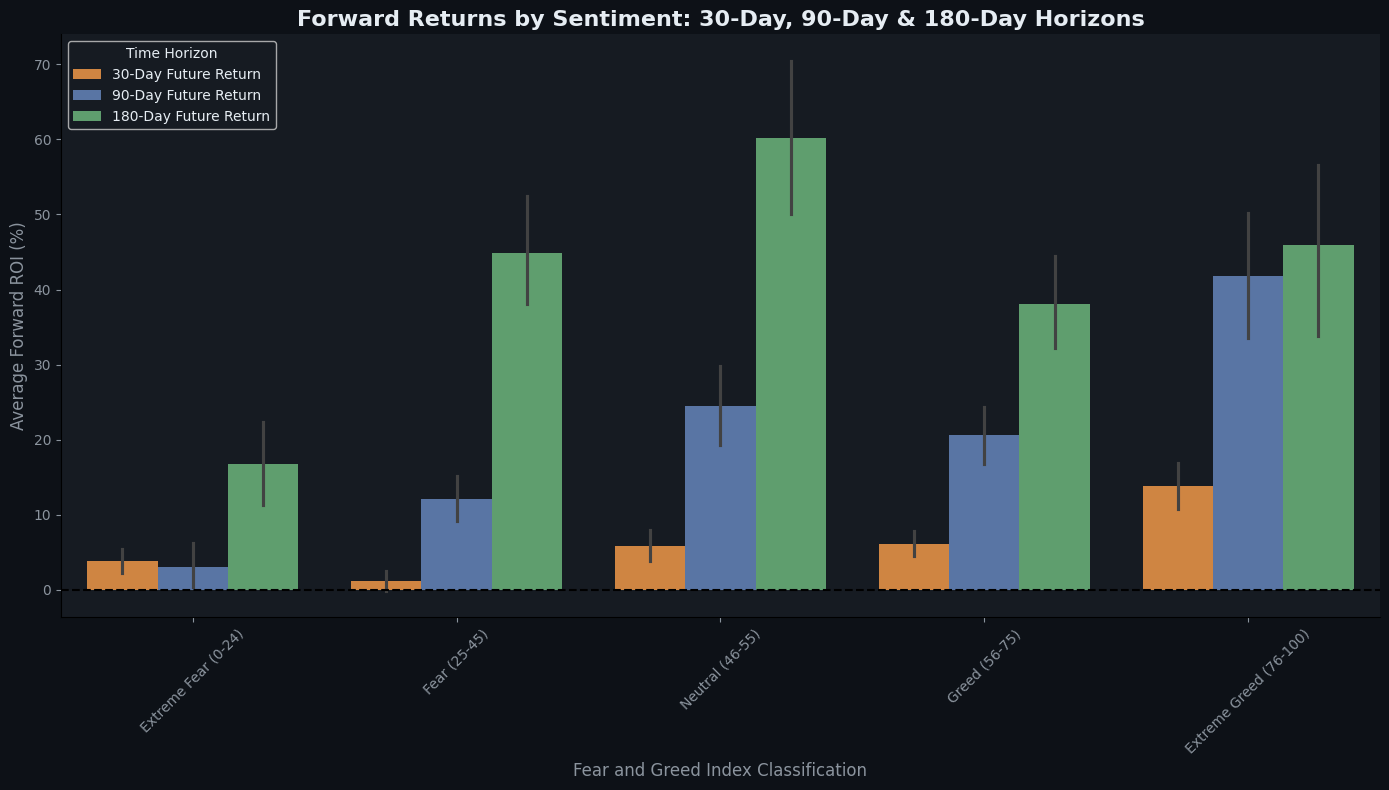

In [71]:
if 'df_long_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_long_analysis['FGI_Bracket'] = pd.cut(df_long_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward returns for all three horizons
    fgi_grouped_30 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI30d'].agg(['mean', 'median'])
    fgi_grouped_90 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI90d'].agg(['mean', 'median'])
    fgi_grouped_180 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI180d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 30-Day Forward Return ---")
    print(fgi_grouped_30)
    print("\n--- Average 90-Day Forward Return ---")
    print(fgi_grouped_90)
    print("\n--- Average 180-Day Forward Return ---")
    print(fgi_grouped_180)
    print("-" * 60)
    
    # 3. Restructure the dataframe to include all three ROI horizons
    df_melted = df_long_analysis.melt(
        id_vars=['FGI_Bracket'], 
        value_vars=['Fwd_ROI30d', 'Fwd_ROI90d', 'Fwd_ROI180d'],
        var_name='ROI_Horizon', 
        value_name='Forward_Return'
    )
    
    # 4. Visualize the non-linear relationship over expanding time horizons
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Use a grouped barplot with three colors
    sns.barplot(
        data=df_melted, 
        x='FGI_Bracket', 
        y='Forward_Return', 
        hue='ROI_Horizon', 
        palette=['#E6842A', '#4C72B0', '#55A868'], # Orange (30d), Blue (90d), Green (180d)
        ax=ax
    )
    
    ax.set_title("Forward Returns by Sentiment: 30-Day, 90-Day & 180-Day Horizons", fontsize=16, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    
    # Prettify the legend to match the three horizons
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['30-Day Future Return', '90-Day Future Return', '180-Day Future Return'], title="Time Horizon", loc='upper left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Strategic Interpretation: Momentum, Mean Reversion, and Market Regimes

The forward-return data across 30, 90, and 180-day horizons challenges traditional contrarian adages (e.g., "buy when there is blood in the streets") and reveals the heavy influence of momentum in Bitcoin market cycles. 


#### What the Data Actually Means:
1. **The Momentum Engine (Extreme Greed):** Over short timeframes (30 days), **Extreme Greed** is highly profitable, boasting a 13.77% average return. Euphoria in crypto markets sustains itself; cycle tops take time to form, and betting against a greedy market prematurely means missing significant upside. However, notice the 180-day median return drops to 8.47%, indicating that over a 6-month horizon, these greedy tops eventually collapse.
2. **The Crypto Winter Trap (Extreme Fear):** Buying maximum fear is statistically dangerous over long horizons. While there is a slight 30-day capitulation bounce (1.77% median), the 90-day and 180-day median returns plunge negative (-2.93% and -2.66%). This proves that "Extreme Fear" does not mark V-shaped recoveries; it marks the beginning of prolonged, grueling bear markets. 
3. **The "Disbelief" Sweet Spot (Neutral):** The most striking finding is the dominance of the **Neutral (46-55)** bracket over long timeframes. Buying when the market is quiet, boring, and emotionally flat yields a staggering 60.18% average and 36.14% median 180-day return. This represents the optimal macroeconomic launchpad—the phase where bear markets have exhausted themselves, but retail FOMO has not yet ignited.

---


This reveals a critical dynamic for our (possibly a) 4-year accumulation and distribution strategy: the utility of market sentiment changes depending on **how much time is left until our scheduled sell date** (e.g., the end of a half-year liquidation target). 


By analyzing short-term momentum versus long-term mean reversion, we can dynamically adjust our accumulation weighting based on our time-to-target:

#### 1. Early in the Period (Far from Sell Target: >90 to 180 Days)
When we are at the beginning of an accumulation period, our time horizon is long, and we must optimize for the 180-day forward returns. 
* **The "Disbelief" Sweet Spot (Neutral 46-55):** This is the optimal macroeconomic launchpad. Buying when the market is emotionally flat yields a staggering 60.18% average and 36.14% median 180-day return. The model should heavily weight accumulation here.
* **Avoid Extreme Greed:** Buying euphoria early in the period is statistically inefficient. While it feels good in the moment, the 180-day median return drops to 8.47%, meaning the cyclical top will likely collapse before our sell date arrives.
* **The "Crypto Winter" Trap (Extreme Fear 0-24):** Buying maximum fear early in a cycle catches a falling knife, evidenced by a negative 180-day median return (-2.66%). The model should stick to a conservative, baseline Dollar Cost Average (DCA) rather than deploying lump-sum capital.

#### 2. Late in the Period (Close to Sell Target: <30 Days)
As we approach the end of the period, our time horizon shrinks, and long-term mean reversion no longer matters. We shift strictly to a momentum-based logic.
* **The Momentum Engine (Extreme Greed 76-100):** If the market hits Extreme Greed close to our liquidation date, it becomes **highly useful to increase buying**. The 30-day forward return is a massive 13.77%. Euphoria in crypto markets sustains itself in the short term, allowing the model to aggressively ride the momentum straight into the target sell date before the inevitable crash occurs.

In the possible future, the accumulation algorithm should use a time-decaying weight system. Extreme Greed triggers profit-taking/reduced buying when the time horizon is long, but it triggers aggressive momentum buying when the time horizon is short enough to safely cash out.

In [72]:
#import sys
#!{sys.executable} -m pip list --format=freeze > requirements.txt

In [73]:
from datetime import datetime
# Get the current date and time
current_time = datetime.now()
# Print the full datetime object
print('Notebook done at:',current_time)

Notebook done at: 2026-04-15 20:47:24.229854


In [74]:
import sys
!{sys.executable} -m pip list --format=freeze > requirements.txt